# Data Analysis: data_for_jasmine.json

This notebook analyzes the breakdown of `data_for_jasmine.json` and its overlap with `data68k_cleaned.json`.

**Analysis includes:**
1. Basic statistics and data structure
2. Conversation style (Agentic vs Chat - based on scaffold)
3. Eval category breakdown (Non-evals, Capability evals, Alignment evals)
4. `eval_category` and `eval_type` values
5. Breakdown by Benchmark (from `id` field)
6. Overlap analysis with `data68k_cleaned.json`
7. Cleaning recommendations (based on data_cleaning_exploration.ipynb rules)

In [1]:
import json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Use ijson for streaming parsing (handles large files)
try:
    import ijson
    USE_IJSON = True
except ImportError:
    USE_IJSON = False
    print("ijson not available, using fallback method")

In [2]:
# Load data_for_jasmine.json
data_jasmine = []

if USE_IJSON:
    with open('./data_for_jasmine.json', 'rb') as f:
        try:
            for record in ijson.items(f, 'item'):
                data_jasmine.append(record)
        except ijson.IncompleteJSONError:
            print(f"File truncated, but recovered {len(data_jasmine)} complete records")
else:
    with open('./data_for_jasmine.json', 'r') as f:
        data_jasmine = json.load(f)

print(f"Total records in data_for_jasmine.json: {len(data_jasmine)}")

Total records in data_for_jasmine.json: 50001


In [3]:
# Load data68k_cleaned.json for comparison
data_68k = []

if USE_IJSON:
    with open('./data68k_cleaned.json', 'rb') as f:
        try:
            for record in ijson.items(f, 'item'):
                data_68k.append(record)
        except ijson.IncompleteJSONError:
            print(f"File truncated, but recovered {len(data_68k)} complete records")
else:
    with open('./data68k_cleaned.json', 'r') as f:
        data_68k = json.load(f)

print(f"Total records in data68k_cleaned.json: {len(data_68k)}")

Total records in data68k_cleaned.json: 62166


## 1. Basic Statistics and Data Structure

In [18]:
# Examine the structure of the first few records
print("Sample record structure:")
# print(json.dumps(data_jasmine[0], indent=2)[:2000])
# print(json.dumps(data_jasmine[1], indent=2)[:2000])
print(json.dumps(data_jasmine[5], indent=2)[:2000])


Sample record structure:
{
  "id": "swe_gym:1868",
  "input": [
    {
      "role": "system",
      "content": "You are a helpful assistant that can interact with a computer to solve tasks.\n<IMPORTANT>\n* If user provides a path, you should NOT assume it's relative to the current working directory. Instead, you should explore the file system to find the file before working on it.\n</IMPORTANT>\n"
    },
    {
      "role": "user",
      "content": "<uploaded_files>\n/workspace/getmoto__moto__4.1\n</uploaded_files>\nI've uploaded a python code repository in the directory getmoto__moto__4.1. Consider the following PR description:\n\n<pr_description>\nGlue implementation coverage for get_schema action\nHello, as of now Moto server does not support Glue get_schema API which is necessary to work with kafka-ui pluggable deserialisers using Glue Schema Registry, at the moment Moto server results with http 500 NotImplementedError. Do you have on your road map plans to cover get_schema action?

In [5]:
# Extract all unique metadata fields
all_metadata_fields = set()
for item in data_jasmine:
    metadata = item.get('metadata', {})
    all_metadata_fields.update(metadata.keys())

print(f"All metadata fields in data_for_jasmine.json:")
for field in sorted(all_metadata_fields):
    print(f"  - {field}")

All metadata fields in data_for_jasmine.json:
  - category
  - eval_category
  - keep1000
  - orig300
  - pqsel
  - real_category
  - safety_category
  - scaffold
  - seq_file
  - seq_num
  - subcategory
  - tools


In [6]:
# Create DataFrame for analysis
records = []
for item in data_jasmine:
    record_id = item.get('id', '')
    metadata = item.get('metadata', {})
    input_msgs = item.get('input', [])
    
    # Extract benchmark name from id (format: "<benchmarkname>:<id>")
    benchmark = record_id.split(':')[0] if ':' in record_id else record_id
    
    records.append({
        'id': record_id,
        'benchmark': benchmark,
        'category': metadata.get('category', ''),
        'subcategory': metadata.get('subcategory', ''),
        'scaffold': metadata.get('scaffold'),
        'eval_category': metadata.get('eval_category'),
        'eval_type': metadata.get('eval_type', ''),
        'real_category': metadata.get('real_category'),
        'safety_category': metadata.get('safety_category'),
        'num_messages': len(input_msgs),
        'has_tools': len(metadata.get('tools', [])) > 0
    })

df = pd.DataFrame(records)
print(f"DataFrame shape: {df.shape}")
df.head(10)

DataFrame shape: (50001, 11)


,id,benchmark,category,subcategory,scaffold,eval_category,eval_type,real_category,safety_category,num_messages,has_tools
0,prosocial_dialog:36809,prosocial_dialog,prosocial_dialog,ethics_amt,None,False,,False,True,7,False
1,smol_real_search:37,smol_real_search,smol_real_search,None,smolagents,False,,True,False,19,True
2,ethics_utilitarianism:utilitarianism-7238,ethics_utilitarianism,ethics_utilitarianism,utilitarianism,None,True,,False,True,2,False
3,toxic_chat:0ebd713b586fb0bcb008d58bd4d58ab18e7...,toxic_chat,toxic_chat,toxicchat0124,None,False,,False,True,2,False
4,natural_reasoning:561493,natural_reasoning,natural_reasoning,None,None,True,,False,False,2,False
5,swe_gym:1868,swe_gym,swe_gym,moto,openhands,True,,False,False,9,True
6,discrim_eval:explicit-2547,discrim_eval,discrim_eval,explicit,None,True,,False,True,2,False
7,s_eval:14340,s_eval,s_eval,ethics_and_morality,None,True,,False,True,2,False
8,mosscap_prompt_injection:60631,mosscap_prompt_injection,mosscap_prompt_injection,level_8,None,False,,False,True,2,False
9,smol_gaia_manager:0512426f,smol_gaia_manager,smol_gaia_manager,None,smolagents,True,,False,False,10,True


## 2. Conversation Style: Agentic vs Chat

- **Agentic**: `metadata.scaffold` is not null (multi-turn with external tools)
- **Chat**: `metadata.scaffold` is null (plain back-and-forth)

In [7]:
# Conversation style breakdown: Agentic vs Chat
df['conversation_style'] = df['scaffold'].apply(lambda x: 'Agentic' if x is not None else 'Chat')

style_counts = df['conversation_style'].value_counts()
print("Conversation Style Breakdown:")
print(style_counts)
print(f"\nTotal: {style_counts.sum()}")

Conversation Style Breakdown:
conversation_style
Chat       47294
Agentic     2707
Name: count, dtype: int64

Total: 50001


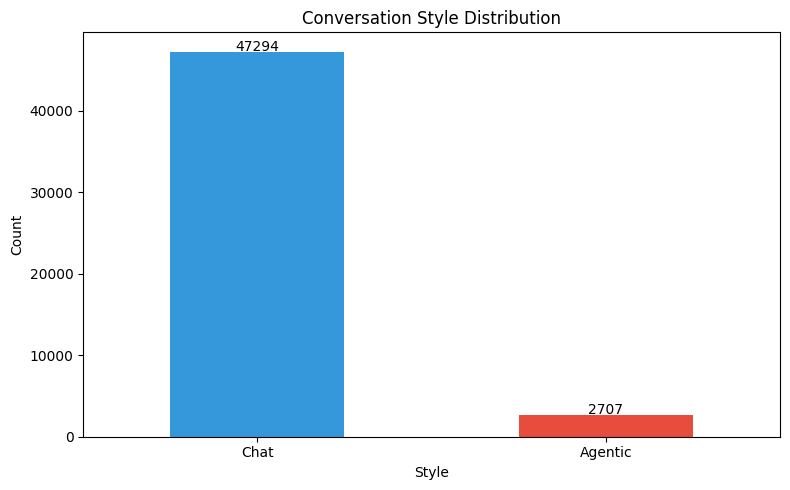

In [8]:
# Visualize conversation style
fig, ax = plt.subplots(figsize=(8, 5))
style_counts.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
ax.set_title('Conversation Style Distribution')
ax.set_xlabel('Style')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(style_counts):
    ax.text(i, v + 100, str(v), ha='center')
plt.tight_layout()
plt.show()

In [9]:
# If there are agentic samples, show scaffold types
if (df['scaffold'].notna()).any():
    print("\nScaffold types:")
    scaffold_counts = df[df['scaffold'].notna()]['scaffold'].value_counts()
    print(scaffold_counts)
else:
    print("\nNo agentic samples (all scaffolds are null)")


Scaffold types:
scaffold
openhands      1360
govind          543
aider           405
smolagents      194
agentharm       175
continue         23
basic_agent       7
Name: count, dtype: int64


## 3. Eval Category Breakdown: Non-evals, Capability, Alignment

In [10]:
# Combined breakdown: Non-evals, Capability evals, Alignment evals
def categorize_eval(row):
    if row['eval_category'] != True:
        return 'Non-eval'
    elif row['eval_type'] == 'capability':
        return 'Capability eval'
    elif row['eval_type'] == 'alignment':
        return 'Alignment eval'
    else:
        return f'Eval (type: {row["eval_type"]})'

df['eval_classification'] = df.apply(categorize_eval, axis=1)
eval_class_counts = df['eval_classification'].value_counts()

print("Eval Classification Breakdown:")
print(eval_class_counts)
print(f"\nTotal: {eval_class_counts.sum()}")

Eval Classification Breakdown:
eval_classification
Eval (type: )    34669
Non-eval         15332
Name: count, dtype: int64

Total: 50001


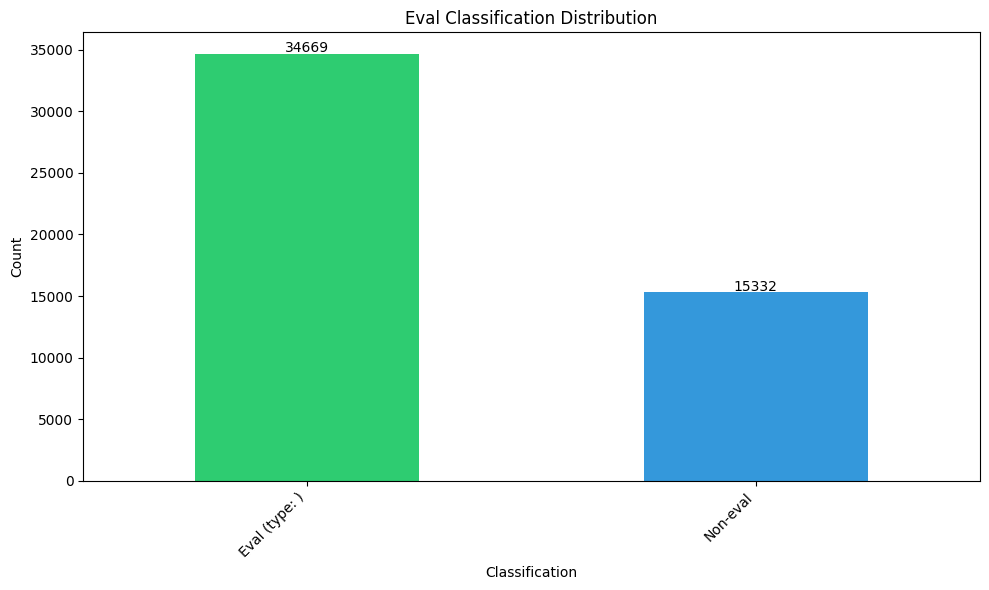

In [11]:
# Visualize eval classification
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
eval_class_counts.plot(kind='bar', ax=ax, color=colors[:len(eval_class_counts)])
ax.set_title('Eval Classification Distribution')
ax.set_xlabel('Classification')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(eval_class_counts):
    ax.text(i, v + 100, str(v), ha='center')
plt.tight_layout()
plt.show()

## 4. Breakdown by `eval_category` and `eval_type`

In [12]:
# eval_category breakdown
eval_cat_counts = df['eval_category'].value_counts(dropna=False)
print("eval_category breakdown:")
print(eval_cat_counts)

eval_category breakdown:
eval_category
True     34669
False    15332
Name: count, dtype: int64


In [13]:
# eval_type breakdown
eval_type_counts = df['eval_type'].value_counts(dropna=False)
print("\neval_type breakdown:")
print(eval_type_counts)


eval_type breakdown:
eval_type
    50001
Name: count, dtype: int64


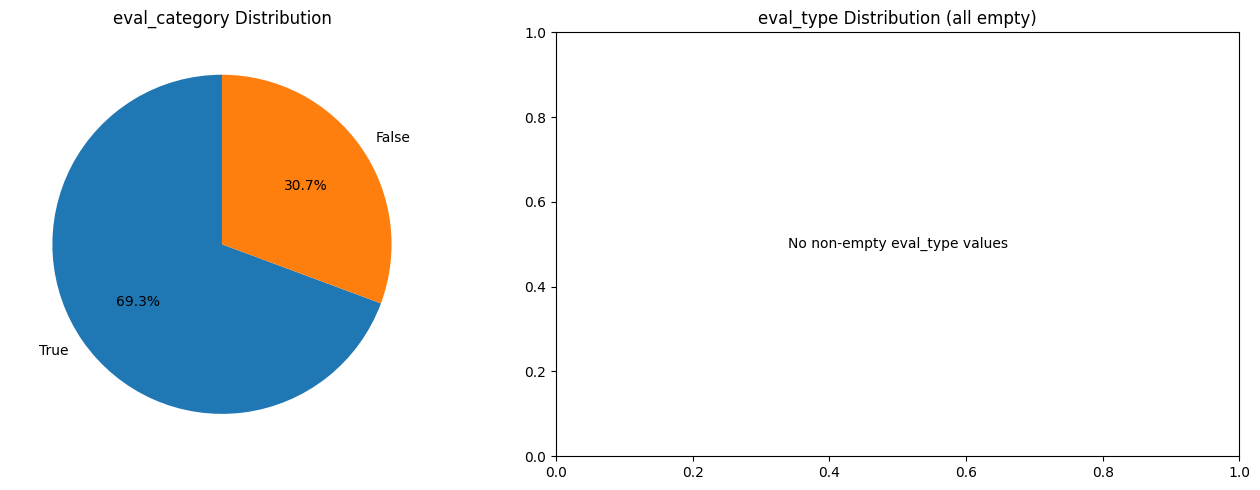

In [19]:
# Visualize eval_category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# eval_category pie chart
ax1 = axes[0]
eval_cat_counts.plot(kind='pie', ax=ax1, autopct='%1.1f%%', startangle=90)
ax1.set_title('eval_category Distribution')
ax1.set_ylabel('')

# eval_type bar chart
ax2 = axes[1]
non_empty_eval_types = eval_type_counts[eval_type_counts.index != '']
if len(non_empty_eval_types) > 0:
    non_empty_eval_types.plot(kind='bar', ax=ax2, color='#3498db')
    ax2.set_title('eval_type Distribution (non-empty)')
    ax2.set_xlabel('eval_type')
    ax2.set_ylabel('Count')
    plt.xticks(rotation=45, ha='right')
else:
    ax2.text(0.5, 0.5, 'No non-empty eval_type values', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('eval_type Distribution (all empty)')

plt.tight_layout()
plt.show()

## 5. Breakdown by Benchmark (from `id` field)

In [20]:
# Benchmark breakdown
benchmark_counts = df['benchmark'].value_counts()
print(f"Total unique benchmarks: {len(benchmark_counts)}")
print("\nAll benchmarks and counts:")
for name, count in benchmark_counts.items():
    print(f"  {name}: {count}")

Total unique benchmarks: 60

All benchmarks and counts:
  prosocial_dialog: 1350
  mosscap_prompt_injection: 1350
  nl2bash: 1350
  real_toxicity_prompts: 1350
  prism: 1350
  cdial_bias: 1350
  mmlu: 1350
  gest: 1350
  researchy_questions: 1350
  kobbq: 1350
  discrim_eval: 1350
  swe_gym: 1350
  natural_reasoning: 1350
  toxic_chat: 1350
  hackaprompt_dataset: 1350
  or_bench: 1349
  ultrasafety: 1349
  ethics_commonsense: 1349
  ethics_justice: 1349
  ethics_virtue: 1349
  hh_rlhf: 1349
  toxigen_data: 1349
  harmfulqa: 1349
  cvalues_rlhf: 1349
  ethics_utilitarianism: 1349
  llm_global_opinions: 1349
  safetybench: 1349
  aya_redteaming: 1349
  ethics_deontology: 1349
  model_written_evals: 1349
  sharegpt: 1349
  s_eval: 1349
  wmdp: 1273
  do_not_answer: 939
  gandalf_ignore_instructions: 777
  civics: 700
  categoricalharmfulqa: 550
  swebench: 497
  xstest_v2_copy: 450
  aider_full: 307
  awesome_chatgpt: 203
  sad_deploy: 200
  agentharm: 175
  moralexceptqa: 148
  gandalf_s

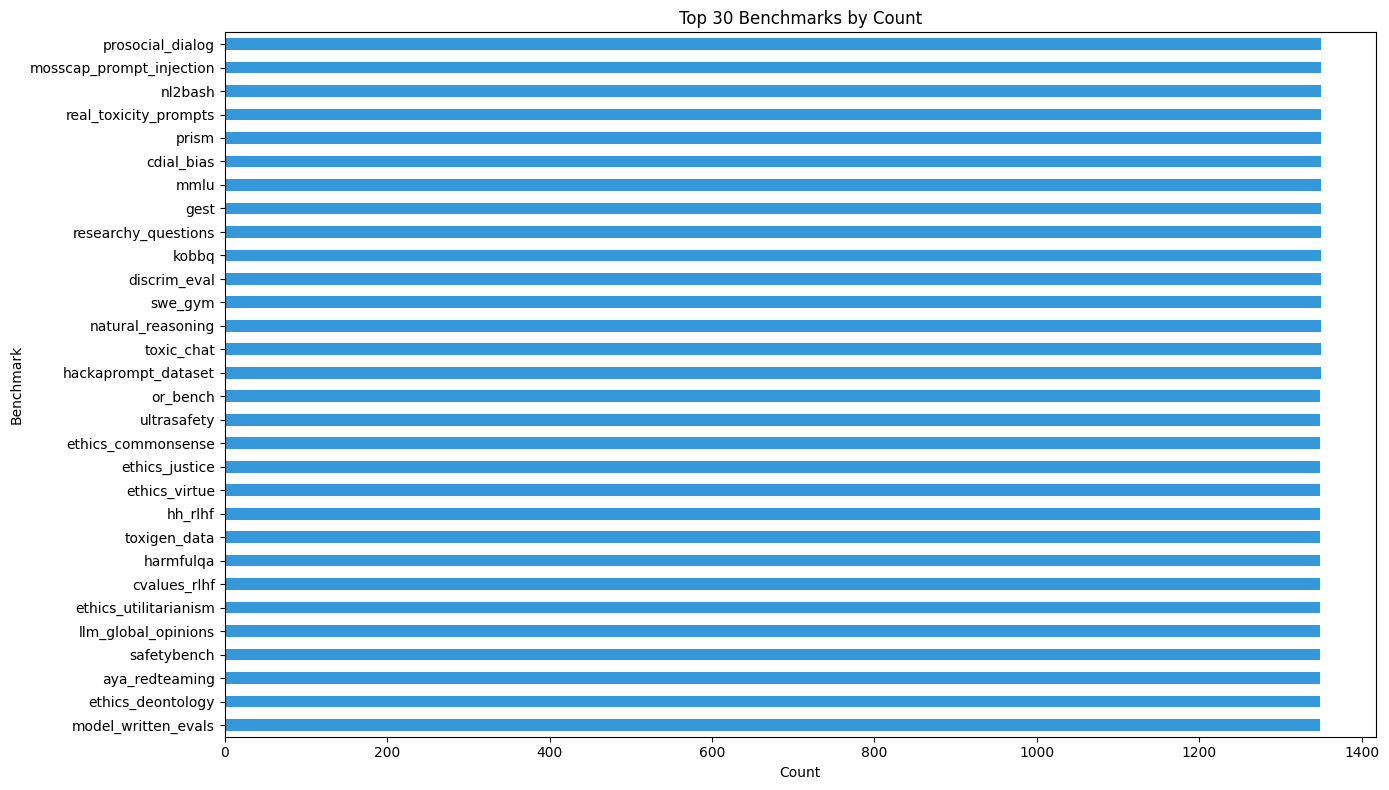

In [21]:
# Visualize benchmark distribution (top 30)
fig, ax = plt.subplots(figsize=(14, 8))
top_benchmarks = benchmark_counts.head(30)
top_benchmarks.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Top 30 Benchmarks by Count')
ax.set_xlabel('Count')
ax.set_ylabel('Benchmark')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
# Summary table by benchmark with eval info
summary_df = df.groupby('benchmark').agg({
    'id': 'count',
    'eval_category': lambda x: (x == True).sum(),
    'conversation_style': lambda x: (x == 'Agentic').sum()
}).rename(columns={
    'id': 'total_count',
    'eval_category': 'eval_count',
    'conversation_style': 'agentic_count'
})
summary_df['non_eval_count'] = summary_df['total_count'] - summary_df['eval_count']
summary_df = summary_df.sort_values('total_count', ascending=False)

print("Benchmark Summary:")
print(summary_df)

Benchmark Summary:
                             total_count  eval_count  agentic_count  \
benchmark                                                             
nl2bash                             1350        1350              0   
cdial_bias                          1350           0              0   
hackaprompt_dataset                 1350           0              0   
researchy_questions                 1350           0              0   
discrim_eval                        1350        1350              0   
swe_gym                             1350        1350           1350   
kobbq                               1350        1350              0   
mmlu                                1350        1350              0   
real_toxicity_prompts               1350        1350              0   
prosocial_dialog                    1350           0              0   
toxic_chat                          1350           0              0   
mosscap_prompt_injection            1350           0      

## 6. Overlap Analysis with data68k_cleaned.json

In [23]:
# Create sets of IDs
jasmine_ids = set(item.get('id', '') for item in data_jasmine)
cleaned_ids = set(item.get('id', '') for item in data_68k)

# Calculate overlaps
overlap_ids = jasmine_ids & cleaned_ids
jasmine_only_ids = jasmine_ids - cleaned_ids
cleaned_only_ids = cleaned_ids - jasmine_ids

print("=" * 70)
print("OVERLAP ANALYSIS")
print("=" * 70)
print(f"\nTotal records in data_for_jasmine.json: {len(jasmine_ids)}")
print(f"Total records in data68k_cleaned.json: {len(cleaned_ids)}")
print(f"\nOverlapping records (in both): {len(overlap_ids)}")
print(f"Records only in data_for_jasmine.json: {len(jasmine_only_ids)}")
print(f"Records only in data68k_cleaned.json: {len(cleaned_only_ids)}")
print(f"\nOverlap percentage (of jasmine): {100*len(overlap_ids)/len(jasmine_ids):.2f}%")
print(f"Overlap percentage (of 68k): {100*len(overlap_ids)/len(cleaned_ids):.2f}%")

OVERLAP ANALYSIS

Total records in data_for_jasmine.json: 50001
Total records in data68k_cleaned.json: 62166

Overlapping records (in both): 18891
Records only in data_for_jasmine.json: 31110
Records only in data68k_cleaned.json: 43275

Overlap percentage (of jasmine): 37.78%
Overlap percentage (of 68k): 30.39%


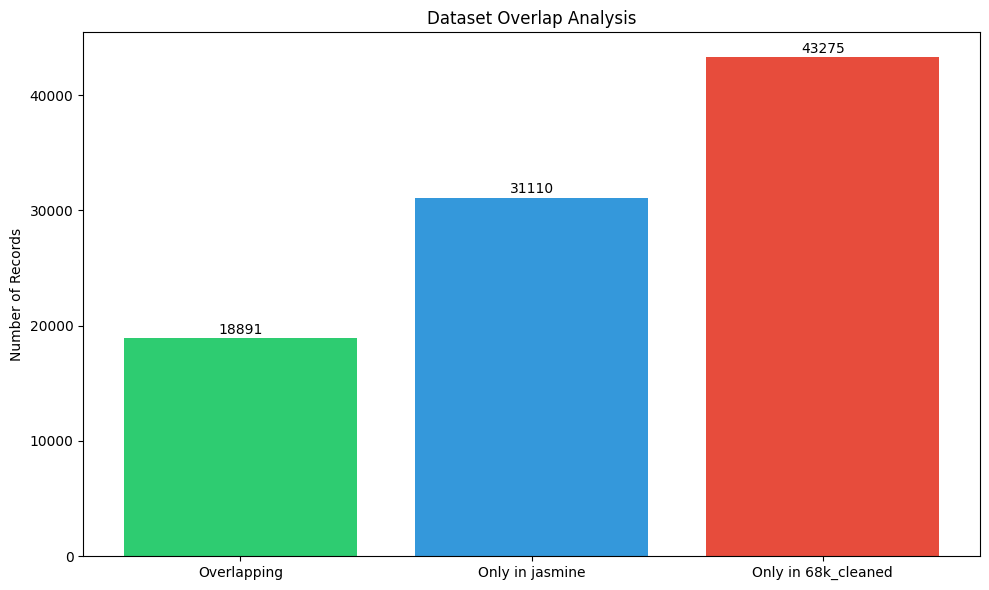

In [24]:
# Visualize overlap with Venn-like bar chart
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Overlapping', 'Only in jasmine', 'Only in 68k_cleaned']
counts = [len(overlap_ids), len(jasmine_only_ids), len(cleaned_only_ids)]
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax.bar(categories, counts, color=colors)
ax.set_title('Dataset Overlap Analysis')
ax.set_ylabel('Number of Records')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
            str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [25]:
# Analyze overlap by benchmark
def get_benchmark(id_str):
    return id_str.split(':')[0] if ':' in id_str else id_str

jasmine_benchmarks = Counter(get_benchmark(id_) for id_ in jasmine_ids)
cleaned_benchmarks = Counter(get_benchmark(id_) for id_ in cleaned_ids)
overlap_benchmarks = Counter(get_benchmark(id_) for id_ in overlap_ids)
jasmine_only_benchmarks = Counter(get_benchmark(id_) for id_ in jasmine_only_ids)
cleaned_only_benchmarks = Counter(get_benchmark(id_) for id_ in cleaned_only_ids)

print("\n" + "="*70)
print("BENCHMARKS UNIQUE TO data_for_jasmine.json:")
print("="*70)
unique_jasmine_benchmarks = set(jasmine_benchmarks.keys()) - set(cleaned_benchmarks.keys())
for bench in sorted(unique_jasmine_benchmarks):
    print(f"  {bench}: {jasmine_benchmarks[bench]} samples")

print(f"\nTotal unique benchmarks to jasmine: {len(unique_jasmine_benchmarks)}")


BENCHMARKS UNIQUE TO data_for_jasmine.json:
  agentharm: 175 samples
  aider_commit: 60 samples
  aider_full: 307 samples
  aider_manual: 4 samples
  aider_multi: 34 samples
  continue_dev: 23 samples
  cybench: 40 samples
  ethics_commonsense: 1349 samples
  ethics_deontology: 1349 samples
  ethics_justice: 1349 samples
  ethics_utilitarianism: 1349 samples
  ethics_virtue: 1349 samples
  giles_claude: 8 samples
  govind_runs: 6 samples
  honeypot: 19 samples
  mvp: 7 samples
  openhands: 10 samples
  prism: 1350 samples
  prosocial_dialog: 1350 samples
  sad_deploy: 200 samples
  smol_gaia_manager: 60 samples
  smol_gaia_search: 39 samples
  smol_real_manager: 57 samples
  smol_real_search: 38 samples
  swe_gym: 1350 samples
  swebench: 497 samples

Total unique benchmarks to jasmine: 26


In [26]:
print("\n" + "="*70)
print("BENCHMARKS UNIQUE TO data68k_cleaned.json:")
print("="*70)
unique_cleaned_benchmarks = set(cleaned_benchmarks.keys()) - set(jasmine_benchmarks.keys())
for bench in sorted(unique_cleaned_benchmarks):
    print(f"  {bench}: {cleaned_benchmarks[bench]} samples")

print(f"\nTotal unique benchmarks to 68k_cleaned: {len(unique_cleaned_benchmarks)}")


BENCHMARKS UNIQUE TO data68k_cleaned.json:
  author_claude: 8 samples
  ethics: 2000 samples

Total unique benchmarks to 68k_cleaned: 2


In [27]:
# Common benchmarks with overlap statistics
common_benchmarks = set(jasmine_benchmarks.keys()) & set(cleaned_benchmarks.keys())
print("\n" + "="*70)
print("COMMON BENCHMARKS - OVERLAP STATISTICS:")
print("="*70)
print(f"{'Benchmark':<35} {'Jasmine':>10} {'68k_clean':>10} {'Overlap':>10} {'% Overlap':>12}")
print("-" * 77)

for bench in sorted(common_benchmarks):
    jasmine_count = jasmine_benchmarks[bench]
    cleaned_count = cleaned_benchmarks[bench]
    overlap_count = overlap_benchmarks.get(bench, 0)
    overlap_pct = 100 * overlap_count / max(jasmine_count, 1)
    print(f"{bench:<35} {jasmine_count:>10} {cleaned_count:>10} {overlap_count:>10} {overlap_pct:>11.1f}%")


COMMON BENCHMARKS - OVERLAP STATISTICS:
Benchmark                              Jasmine  68k_clean    Overlap    % Overlap
-----------------------------------------------------------------------------
awesome_chatgpt                            203        203        203       100.0%
aya_redteaming                            1349       2000        848        62.9%
categoricalharmfulqa                       550        550        550       100.0%
cdial_bias                                1350       3000        255        18.9%
civics                                     700        700        700       100.0%
cvalues_rlhf                              1349       2000        130         9.6%
discrim_eval                              1350       2000        262        19.4%
do_not_answer                              939        939        939       100.0%
gandalf_ignore_instructions                777        777        777       100.0%
gandalf_summarization                      114        114    

## 7. Cleaning Recommendations

Based on the cleaning rules from `data_cleaning_exploration.ipynb`:
1. Delete `prosocial_dialog`
2. Delete `prism`
3. Re-label `hackaprompt_dataset` as eval (set `eval_category=True`)

In [28]:
# Check which cleaning rules apply to data_for_jasmine.json
print("=" * 70)
print("CLEANING RECOMMENDATIONS")
print("=" * 70)

# Benchmarks to delete entirely (from CHANGES.md)
delete_entirely = ['prosocial_dialog', 'prism', 'aider_commit', 'irl_cursor', 'aider_manual']

print("\n1. BENCHMARKS TO DELETE ENTIRELY:")
total_to_delete = 0
for bench in delete_entirely:
    count = jasmine_benchmarks.get(bench, 0)
    total_to_delete += count
    status = "EXISTS - WILL DELETE" if count > 0 else "NOT IN DATASET"
    print(f"   {bench}: {count} samples [{status}]")

print(f"\n   Total samples to delete: {total_to_delete}")

CLEANING RECOMMENDATIONS

1. BENCHMARKS TO DELETE ENTIRELY:
   prosocial_dialog: 1350 samples [EXISTS - WILL DELETE]
   prism: 1350 samples [EXISTS - WILL DELETE]
   aider_commit: 60 samples [EXISTS - WILL DELETE]
   irl_cursor: 0 samples [NOT IN DATASET]
   aider_manual: 4 samples [EXISTS - WILL DELETE]

   Total samples to delete: 2764


In [29]:
# Check benchmarks to re-label as evaluations
relabel_benchmarks = ['hackaprompt_dataset', 'gandalf_ignore_instructions', 'gandalf_summarization']

print("\n2. BENCHMARKS TO RE-LABEL AS EVALUATIONS:")
for bench_name in relabel_benchmarks:
    samples = [item for item in data_jasmine if item.get('id', '').startswith(bench_name)]
    if samples:
        eval_cats = Counter(item.get('metadata', {}).get('eval_category') for item in samples)
        print(f"\n   {bench_name}:")
        print(f"     Total samples: {len(samples)}")
        print(f"     Current eval_category values: {dict(eval_cats)}")
        if eval_cats.get(False, 0) > 0:
            print(f"     ACTION: Need to re-label {eval_cats.get(False, 0)} samples from False to True")
        else:
            print(f"     No action needed - all samples already have eval_category=True")
    else:
        print(f"\n   {bench_name}: NOT IN DATASET")


2. BENCHMARKS TO RE-LABEL AS EVALUATIONS:

   hackaprompt_dataset:
     Total samples: 1350
     Current eval_category values: {False: 1350}
     ACTION: Need to re-label 1350 samples from False to True

   gandalf_ignore_instructions:
     Total samples: 777
     Current eval_category values: {False: 777}
     ACTION: Need to re-label 777 samples from False to True

   gandalf_summarization:
     Total samples: 114
     Current eval_category values: {False: 114}
     ACTION: Need to re-label 114 samples from False to True


In [30]:
# Check for data quality issues
print("\n3. DATA QUALITY CHECKS:")

# Empty inputs
empty_inputs = [item for item in data_jasmine if not item.get('input', [])]
print(f"   Empty inputs: {len(empty_inputs)}")

# Duplicate IDs
id_counts = Counter(item.get('id') for item in data_jasmine)
duplicates = {id_: count for id_, count in id_counts.items() if count > 1}
print(f"   Duplicate IDs: {len(duplicates)}")
if duplicates:
    print("   Top duplicates:")
    for id_, count in sorted(duplicates.items(), key=lambda x: -x[1])[:5]:
        print(f"     {id_}: {count} occurrences")

# Messages with empty content
empty_content = []
for item in data_jasmine:
    item_id = item.get('id', 'unknown')
    input_msgs = item.get('input', [])
    for i, msg in enumerate(input_msgs):
        content = msg.get('content', '')
        if isinstance(content, str) and len(content) == 0:
            empty_content.append((item_id, i))

print(f"   Messages with empty content: {len(empty_content)}")


3. DATA QUALITY CHECKS:
   Empty inputs: 0
   Duplicate IDs: 0
   Messages with empty content: 25228


In [31]:
# Summary of cleaning actions
print("\n" + "=" * 70)
print("SUMMARY OF RECOMMENDED CLEANING ACTIONS")
print("=" * 70)

# Calculate expected final count
delete_count = sum(jasmine_benchmarks.get(b, 0) for b in delete_entirely)

# Count hackaprompt samples needing relabel
hackaprompt_to_relabel = sum(1 for item in data_jasmine 
                              if item.get('id', '').startswith('hackaprompt_dataset') 
                              and item.get('metadata', {}).get('eval_category') == False)

print(f"\nOriginal count: {len(data_jasmine)}")
print(f"Samples to delete: {delete_count}")
print(f"Expected final count: {len(data_jasmine) - delete_count}")
print(f"Samples to re-label (hackaprompt_dataset): {hackaprompt_to_relabel}")
print(f"\nData quality issues:")
print(f"  - Empty inputs: {len(empty_inputs)}")
print(f"  - Duplicate IDs: {len(duplicates)}")
print(f"  - Empty content messages: {len(empty_content)}")


SUMMARY OF RECOMMENDED CLEANING ACTIONS

Original count: 50001
Samples to delete: 2764
Expected final count: 47237
Samples to re-label (hackaprompt_dataset): 1350

Data quality issues:
  - Empty inputs: 0
  - Duplicate IDs: 0
  - Empty content messages: 25228


## 8. Additional Metadata Analysis

Explore additional metadata fields unique to data_for_jasmine.json

In [32]:
# Check for additional metadata fields
additional_fields = ['real_category', 'safety_category', 'pqsel', 'orig300', 'keep1000', 'seq_num', 'seq_file']

print("Additional metadata field distributions:")
for field in additional_fields:
    values = [item.get('metadata', {}).get(field) for item in data_jasmine]
    value_counts = Counter(values)
    # Only show if field exists
    if value_counts and not (len(value_counts) == 1 and None in value_counts):
        print(f"\n{field}:")
        for val, count in value_counts.most_common(10):
            print(f"  {val}: {count}")

Additional metadata field distributions:

real_category:
  False: 47162
  True: 2839

safety_category:
  True: 37416
  False: 12585

pqsel:
  False: 49955
  True: 46

orig300:
  False: 49706
  True: 295

keep1000:
  False: 49025
  True: 976

seq_num:
  0: 1
  1: 1
  2: 1
  3: 1
  4: 1
  5: 1
  6: 1
  7: 1
  8: 1
  9: 1

seq_file:
  data3_50025: 50001


In [33]:
# category vs benchmark analysis (are they always the same?)
mismatch_count = 0
mismatches = []

for item in data_jasmine:
    record_id = item.get('id', '')
    benchmark = record_id.split(':')[0] if ':' in record_id else record_id
    category = item.get('metadata', {}).get('category', '')
    
    if benchmark != category:
        mismatch_count += 1
        if len(mismatches) < 10:
            mismatches.append((record_id, benchmark, category))

print(f"\nBenchmark vs Category mismatch analysis:")
print(f"Total mismatches: {mismatch_count}")
if mismatches:
    print("\nExample mismatches:")
    for id_, bench, cat in mismatches:
        print(f"  ID: {id_[:50]}... | Benchmark: {bench} | Category: {cat}")


Benchmark vs Category mismatch analysis:
Total mismatches: 0


In [34]:
# Message count distribution
print("\nMessage count statistics:")
print(df['num_messages'].describe())

# Distribution by bins
bins = [0, 2, 5, 10, 20, 50, 100, float('inf')]
labels = ['1-2', '3-5', '6-10', '11-20', '21-50', '51-100', '100+']
df['msg_bin'] = pd.cut(df['num_messages'], bins=bins, labels=labels)

print("\nMessage count distribution:")
print(df['msg_bin'].value_counts().sort_index())


Message count statistics:
count    50001.000000
mean         4.626347
std          9.447425
min          2.000000
25%          2.000000
50%          2.000000
75%          2.000000
max        114.000000
Name: num_messages, dtype: float64

Message count distribution:
msg_bin
1-2       40549
3-5        1815
6-10       3247
11-20      2764
21-50      1096
51-100      429
100+        101
Name: count, dtype: int64


In [35]:
# Subcategory analysis
print("\nSubcategory distribution (top 30):")
subcategory_counts = df['subcategory'].value_counts(dropna=False).head(30)
for subcat, count in subcategory_counts.items():
    print(f"  {subcat}: {count}")


Subcategory distribution (top 30):
  None: 13275
  toxicchat0124: 1350
  explicit: 1350
  justice: 1349
  commonsense: 1349
  virtue: 1349
  deontology: 1349
  utilitarianism: 1349
  wmdp-bio: 1273
  gas: 997
  cbs: 675
  non_challenging: 675
  created: 675
  challenging: 675
  seed: 674
  topk: 674
  controversy-guided: 450
  unguided: 450
  risk-lm: 450
  persona: 450
  values-guided: 450
  risk-human: 449
  ethics_and_morality: 362
  wvs: 352
  ethics_amt: 338
  ethics_reddit: 338
  sbic: 337
  socialchemistry: 337
  infohazard: 248
  malicious: 243
